In [ ]:
# Healthcare Readmission Analysis

## Project Overview


In [52]:
#load in the datasets and libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("healthcare_raw_data.csv")
df.head()


,Patient_ID,Age,Gender,Race,Height_cm,Weight_kg,BMI,Blood_Pressure,Cholesterol,Glucose,...,Medication_Count,Hospital_Visits_Last_Year,Insurance_Type,Income_Level,City,Admission_Date,Discharge_Date,Length_of_Stay,Total_Hospital_Cost,Readmitted_30_Days
0,P0001,72,Male,Black,174,92,30.4,148/92,241,132,...,6,4,Medicare,Low,Baltimore,2026-01-04,2026-01-11,7,"$14,220.50",Yes
1,P0002,29,female,White,165,61,22.4,118/76,176,91,...,0,0,Private,Medium,Boston,01/08/2026,01/10/2026,2,"$3,180.00",No
2,P0003,64,MALE,Hispanic,68,98,32.9,145/88,263,142,...,5,3,Medicaid,Low,New Yrok,2026-01-11,2026-01-18,7,"$13,750.75",Yes
3,P0004,45,Female,Asian,160,77,30.1,132/84,198,126,...,2,1,Private,Medium,Chicago,01/12/2026,01/16/2026,4,"$7,930.20",No
4,P0005,83,male,Black,171,88,30.1,156/95,255,151,...,8,5,Medicare,Low,Detroit,2026-01-15,2026-01-25,10,"$21,400.90",Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 50 non-null     object 
 1   Age                        50 non-null     int64  
 2   Gender                     50 non-null     object 
 3   Race                       50 non-null     object 
 4   Height_cm                  50 non-null     int64  
 5   Weight_kg                  50 non-null     int64  
 6   BMI                        50 non-null     float64
 7   Blood_Pressure             50 non-null     object 
 8   Cholesterol                50 non-null     int64  
 9   Glucose                    50 non-null     int64  
 10  Heart_Rate                 50 non-null     int64  
 11  Smoking_Status             50 non-null     object 
 12  Alcohol_Use                30 non-null     object 
 13  Exercise_Frequency         50 non-null     object 
 

In [3]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Cholesterol,Glucose,Heart_Rate,Medication_Count,Hospital_Visits_Last_Year,Length_of_Stay
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000
mean,58.600000,147.600000,83.200000,29.180000,226.600000,128.400000,85.00000,4.200000,2.600000,6.000000
std,19.510332,40.499937,13.176974,3.585344,34.158096,20.766928,8.08122,2.885573,1.873554,2.784798
min,29.000000,68.000000,61.000000,22.400000,176.000000,91.000000,72.00000,0.000000,0.000000,2.000000
25%,45.000000,160.000000,77.000000,30.100000,198.000000,126.000000,80.00000,2.000000,1.000000,4.000000
50%,64.000000,165.000000,88.000000,30.100000,241.000000,132.000000,88.00000,5.000000,3.000000,7.000000
75%,72.000000,171.000000,92.000000,30.400000,255.000000,142.000000,91.00000,6.000000,4.000000,7.000000
max,83.000000,174.000000,98.000000,32.900000,263.000000,151.000000,94.00000,8.000000,5.000000,10.000000


In [5]:
df.shape

(50, 27)

In [168]:
df.dtypes

Patient_ID                           object
Age                                   int64
Gender                               object
Race                                 object
Height_cm                             int64
Weight_kg                             int64
BMI                                 float64
Blood_Pressure                       object
Cholesterol                           int64
Glucose                               int64
Heart_Rate                            int64
Smoking_Status                       object
Alcohol_Use                          object
Exercise_Frequency                   object
Diabetes                             object
Hypertension                         object
Heart_Disease                        object
Medication_Count                      int64
Hospital_Visits_Last_Year             int64
Insurance_Type                       object
Income_Level                         object
City                                 object
Admission_Date               dat

In [6]:
df.isnull().sum() #finding missing values

Patient_ID                    0
Age                           0
Gender                        0
Race                          0
Height_cm                     0
Weight_kg                     0
BMI                           0
Blood_Pressure                0
Cholesterol                   0
Glucose                       0
Heart_Rate                    0
Smoking_Status                0
Alcohol_Use                  20
Exercise_Frequency            0
Diabetes                      0
Hypertension                  0
Heart_Disease                 0
Medication_Count              0
Hospital_Visits_Last_Year     0
Insurance_Type                0
Income_Level                  0
City                          0
Admission_Date                0
Discharge_Date                0
Length_of_Stay                0
Total_Hospital_Cost           0
Readmitted_30_Days            0
dtype: int64

In [8]:
df.duplicated().sum() #finding duplicated rows

np.int64(0)

In [10]:
df["Alcohol_Use"] = df["Alcohol_Use"].fillna("Unknown") #filling in missing values

In [11]:
df["Alcohol_Use"].isnull().sum()

np.int64(0)

In [12]:
df.isnull().sum() #checking to see if missing values are filled

Patient_ID                   0
Age                          0
Gender                       0
Race                         0
Height_cm                    0
Weight_kg                    0
BMI                          0
Blood_Pressure               0
Cholesterol                  0
Glucose                      0
Heart_Rate                   0
Smoking_Status               0
Alcohol_Use                  0
Exercise_Frequency           0
Diabetes                     0
Hypertension                 0
Heart_Disease                0
Medication_Count             0
Hospital_Visits_Last_Year    0
Insurance_Type               0
Income_Level                 0
City                         0
Admission_Date               0
Discharge_Date               0
Length_of_Stay               0
Total_Hospital_Cost          0
Readmitted_30_Days           0
dtype: int64

In [113]:
 df["Admission_Date"] = pd.to_datetime(df["Admission_Date"], format='mixed' ) #changing the date to the correct format

In [15]:
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"], format='mixed') #changing the date to the correct format

In [18]:
df.head()

,Patient_ID,Age,Gender,Race,Height_cm,Weight_kg,BMI,Blood_Pressure,Cholesterol,Glucose,...,Medication_Count,Hospital_Visits_Last_Year,Insurance_Type,Income_Level,City,Admission_Date,Discharge_Date,Length_of_Stay,Total_Hospital_Cost,Readmitted_30_Days
0,P0001,72,Male,Black,174,92,30.4,148/92,241,132,...,6,4,Medicare,Low,Baltimore,2026-01-04,2026-01-11,7,"$14,220.50",Yes
1,P0002,29,female,White,165,61,22.4,118/76,176,91,...,0,0,Private,Medium,Boston,2026-01-08,2026-01-10,2,"$3,180.00",No
2,P0003,64,MALE,Hispanic,68,98,32.9,145/88,263,142,...,5,3,Medicaid,Low,New Yrok,2026-01-11,2026-01-18,7,"$13,750.75",Yes
3,P0004,45,Female,Asian,160,77,30.1,132/84,198,126,...,2,1,Private,Medium,Chicago,2026-01-12,2026-01-16,4,"$7,930.20",No
4,P0005,83,male,Black,171,88,30.1,156/95,255,151,...,8,5,Medicare,Low,Detroit,2026-01-15,2026-01-25,10,"$21,400.90",Yes


In [20]:
df.corr

<bound method DataFrame.corr of    Patient_ID  Age  Gender      Race  Height_cm  Weight_kg   BMI  \
0       P0001   72    Male     Black        174         92  30.4   
1       P0002   29  female     White        165         61  22.4   
2       P0003   64    MALE  Hispanic         68         98  32.9   
3       P0004   45  Female     Asian        160         77  30.1   
4       P0005   83    male     Black        171         88  30.1   
5       P0006   72    Male     Black        174         92  30.4   
6       P0007   29  female     White        165         61  22.4   
7       P0008   64    MALE  Hispanic         68         98  32.9   
8       P0009   45  Female     Asian        160         77  30.1   
9       P0010   83    male     Black        171         88  30.1   
10      P0011   72    Male     Black        174         92  30.4   
11      P0012   29  female     White        165         61  22.4   
12      P0013   64    MALE  Hispanic         68         98  32.9   
13      P0014   

In [114]:
df["Gender"] = df["Gender"].str.title() #standarizing gender values

In [115]:
df.head()

,Patient_ID,Age,Gender,Race,Height_cm,Weight_kg,BMI,Blood_Pressure,Cholesterol,Glucose,...,Medication_Count,Hospital_Visits_Last_Year,Insurance_Type,Income_Level,City,Admission_Date,Discharge_Date,Length_of_Stay,Total_Hospital_Cost,Readmitted_30_Days
0,P0001,72,Male,Black,174,92,30.4,148/92,241,132,...,6,4,Medicare,Low,Baltimore,2026-01-04,2026-01-11,7,"$14,220.50",Yes
1,P0002,29,Female,White,165,61,22.4,118/76,176,91,...,0,0,Private,Medium,Boston,2026-01-08,01/10/2026,2,"$3,180.00",No
2,P0003,64,Male,Hispanic,68,98,32.9,145/88,263,142,...,5,3,Medicaid,Low,New Yrok,2026-01-11,2026-01-18,7,"$13,750.75",Yes
3,P0004,45,Female,Asian,160,77,30.1,132/84,198,126,...,2,1,Private,Medium,Chicago,2026-01-12,01/16/2026,4,"$7,930.20",No
4,P0005,83,Male,Black,171,88,30.1,156/95,255,151,...,8,5,Medicare,Low,Detroit,2026-01-15,2026-01-25,10,"$21,400.90",Yes


In [116]:
df["City"].unique()

array([' Baltimore ', 'Boston', 'New Yrok', 'Chicago', 'Detroit'],
      dtype=object)

In [117]:
df["City"] = df["City"].replace({
    "New Yrok": "New York"
}) #correcting the city names

In [118]:
df["City"].unique()

array([' Baltimore ', 'Boston', 'New York', 'Chicago', 'Detroit'],
      dtype=object)

In [119]:
df.to_csv("healthcare_cleaned.csv", index=False)

In [120]:
df.to_string


<bound method DataFrame.to_string of    Patient_ID  Age  Gender      Race  Height_cm  Weight_kg   BMI  \
0       P0001   72    Male     Black        174         92  30.4   
1       P0002   29  Female     White        165         61  22.4   
2       P0003   64    Male  Hispanic         68         98  32.9   
3       P0004   45  Female     Asian        160         77  30.1   
4       P0005   83    Male     Black        171         88  30.1   
5       P0006   72    Male     Black        174         92  30.4   
6       P0007   29  Female     White        165         61  22.4   
7       P0008   64    Male  Hispanic         68         98  32.9   
8       P0009   45  Female     Asian        160         77  30.1   
9       P0010   83    Male     Black        171         88  30.1   
10      P0011   72    Male     Black        174         92  30.4   
11      P0012   29  Female     White        165         61  22.4   
12      P0013   64    Male  Hispanic         68         98  32.9   
13      P00

In [121]:
df["Hypertension"].unique() #checking for inconsistent values

array(['TRUE', 'No', 'yes', 'Y'], dtype=object)

In [122]:
df["Hypertension"] = df["Hypertension"].replace({
    "yes": "Yes",
    "Y": "Yes",
    "TRUE": "Yes"
})

In [123]:
df["Hypertension"].unique()

array(['Yes', 'No'], dtype=object)

In [124]:
df["Diabetes"].unique()

array(['Yes', 'No'], dtype=object)

In [125]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Cholesterol,Glucose,Heart_Rate,Medication_Count,Hospital_Visits_Last_Year,Admission_Date,Length_of_Stay
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50,50.000000
mean,58.600000,147.600000,83.200000,29.180000,226.600000,128.400000,85.00000,4.200000,2.600000,2026-01-10 00:00:00,6.000000
min,29.000000,68.000000,61.000000,22.400000,176.000000,91.000000,72.00000,0.000000,0.000000,2026-01-04 00:00:00,2.000000
25%,45.000000,160.000000,77.000000,30.100000,198.000000,126.000000,80.00000,2.000000,1.000000,2026-01-08 00:00:00,4.000000
50%,64.000000,165.000000,88.000000,30.100000,241.000000,132.000000,88.00000,5.000000,3.000000,2026-01-11 00:00:00,7.000000
75%,72.000000,171.000000,92.000000,30.400000,255.000000,142.000000,91.00000,6.000000,4.000000,2026-01-12 00:00:00,7.000000
max,83.000000,174.000000,98.000000,32.900000,263.000000,151.000000,94.00000,8.000000,5.000000,2026-01-15 00:00:00,10.000000
std,19.510332,40.499937,13.176974,3.585344,34.158096,20.766928,8.08122,2.885573,1.873554,NaN,2.784798


In [126]:
print("Average Age:", df["Age"].mean())
print("Median Age:", df["Age"].median())
print("Oldest patient:", df["Age"].max())
print("Youngest patient:", df["Age"].min())

Average Age: 58.6
Median Age: 64.0
Oldest patient: 83
Youngest patient: 29


In [162]:
df["Total_Hospital_Cost"] = (
    df["Total_Hospital_Cost"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["Total_Hospital_Cost"] = pd.to_numeric(
    df["Total_Hospital_Cost"],
    errors="coerce"
)

In [163]:
df["Total_Hospital_Cost"].head()

0    14220.50
1     3180.00
2    13750.75
3     7930.20
4    21400.90
Name: Total_Hospital_Cost, dtype: float64

In [167]:
df["Discharge_Date"] = pd.to_datetime(
    df["Discharge_Date"],
    errors="coerce"
)

In [174]:
df.to_csv("healthcare_cleaned.csv", index=False)

In [128]:
df["Age"].value_counts().sort_index()

Age
29    10
45    10
64    10
72    10
83    10
Name: count, dtype: int64

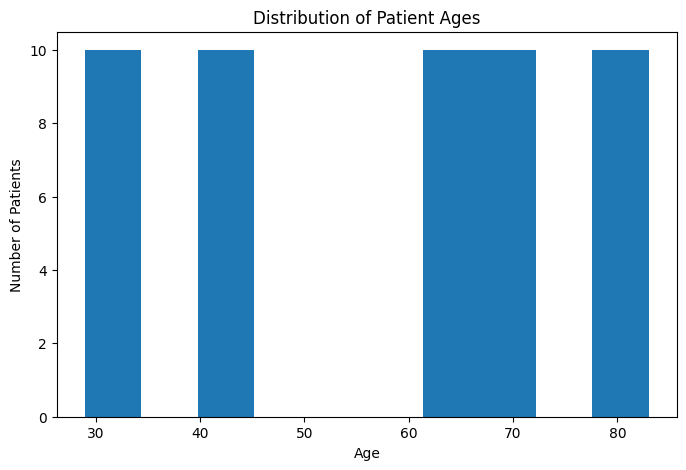

In [129]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10)
plt.title("Distribution of Patient Ages")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()


In [130]:
df.groupby("Smoking_Status")["Cholesterol"].mean()

Smoking_Status
Current    263.0
Former     248.0
Never      187.0
Name: Cholesterol, dtype: float64

In [131]:
df["Gender"] = (
    df["Gender"]
    .str.strip() ###removes spaces
    .str.title() ###capitalizes the first letter of each value
)

In [132]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [133]:
df["Gender"].value_counts()

Gender
Male      30
Female    20
Name: count, dtype: int64

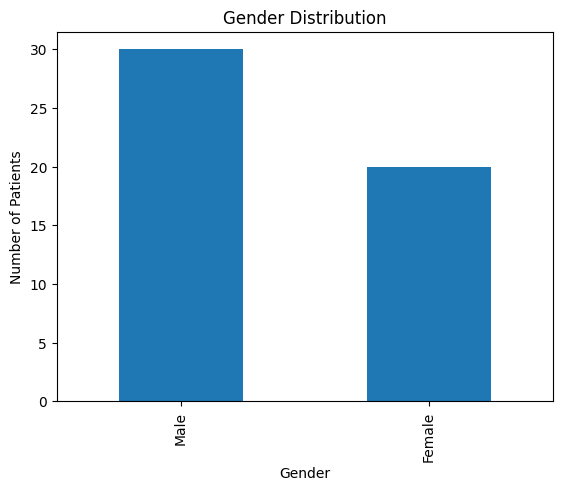

In [134]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show() ###More Male patients than Female patients

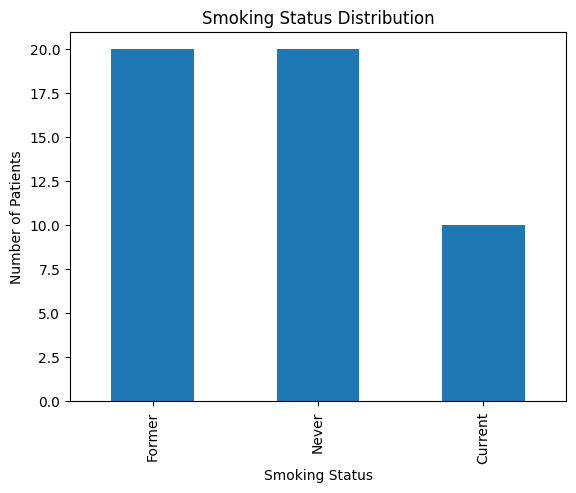

In [135]:
df["Smoking_Status"].value_counts().plot(kind="bar")

plt.title("Smoking Status Distribution")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")
plt.show()

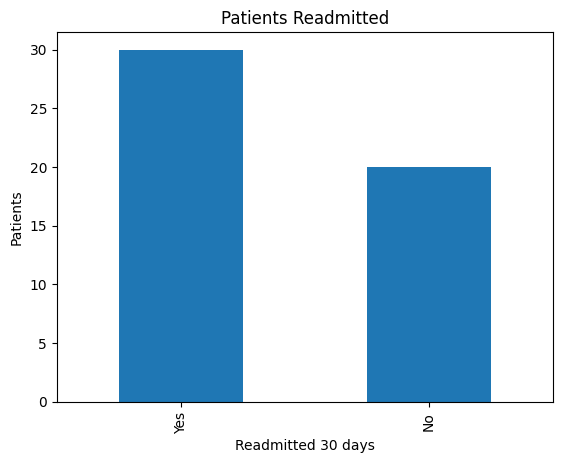

In [136]:
df["Readmitted_30_Days"].value_counts().plot(kind="bar")

plt.title("Patients Readmitted")
plt.xlabel("Readmitted 30 days")
plt.ylabel("Patients")
plt.show()

In [137]:
df["Diabetes"] = df["Diabetes"].replace({
    "Y": "Yes",
    "True": "Yes"
}) ###replacing inconsistent values

In [138]:
df["Diabetes"] = (
    df["Diabetes"]
    .str.strip()   
    .str.title()
)

In [139]:
df["Diabetes"].unique()

array(['Yes', 'No'], dtype=object)

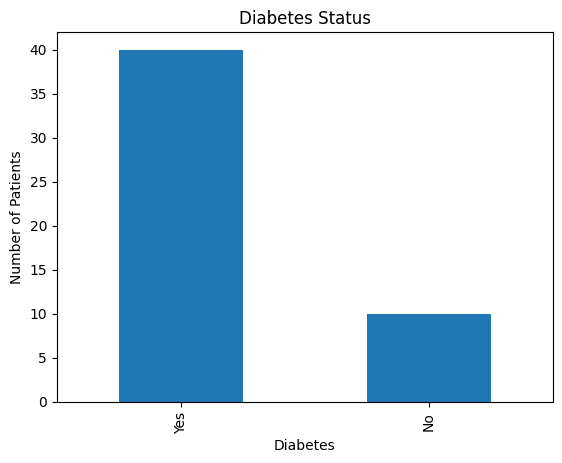

In [140]:
df["Diabetes"].value_counts().plot(kind="bar")

plt.title("Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("Number of Patients")

plt.show()
### They're are a lot of patients who has diabetes

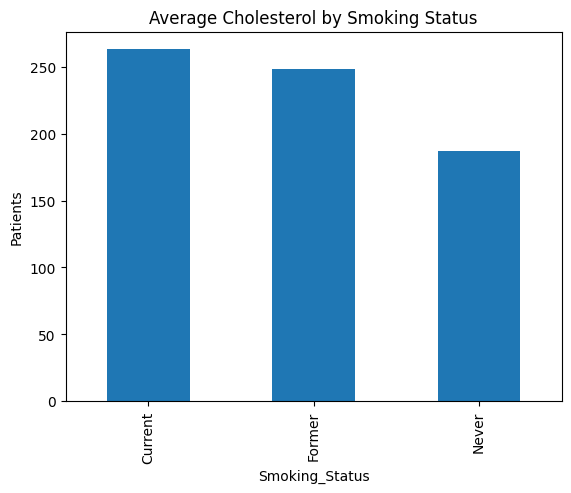

In [141]:
df.groupby("Smoking_Status")["Cholesterol"].mean().plot(kind="bar")

plt.title("Average Cholesterol by Smoking Status")
plt.ylabel("Patients")
plt.show() ###Current and former Smokers have higher cholesterol than people who have never smoked

In [142]:
pd.crosstab(          #Combination of values
    df["Diabetes"],
    df["Readmitted_30_Days"]
) ##If the patient has diabetes they are more likely to ge readmitted to the hospital

Readmitted_30_Days,No,Yes
Diabetes,,
No,10,0
Yes,10,30


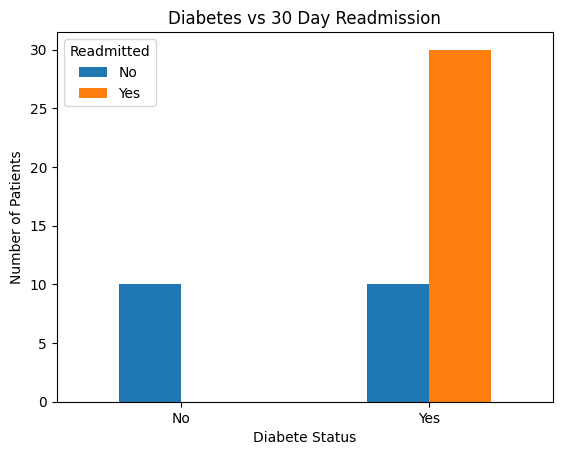

In [143]:
pd.crosstab(          #Combination of values
    df["Diabetes"],
    df["Readmitted_30_Days"]
).plot(
    kind="bar",
    rot=0
)
plt.title("Diabetes vs 30 Day Readmission")
plt.xlabel("Diabete Status")
plt.ylabel("Number of Patients")
plt.legend(title="Readmitted")

plt.show()
    

In [146]:
pd.crosstab(
    df["Hypertension"],
    df["Readmitted_30_Days"]
)

Readmitted_30_Days,No,Yes
Hypertension,,
No,20,0
Yes,0,30


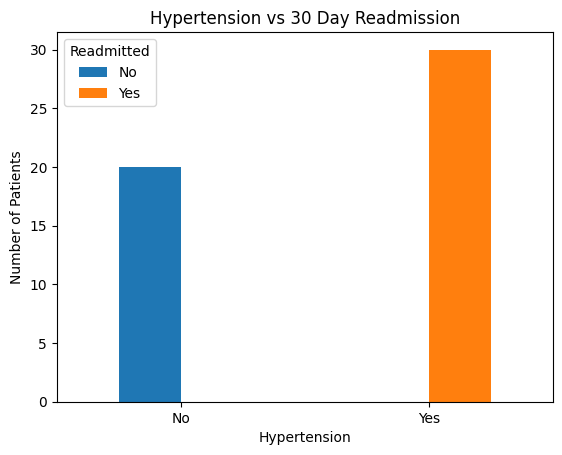

In [144]:
pd.crosstab(
    df["Hypertension"],
    df["Readmitted_30_Days"]
).plot(
    kind="bar",
    rot=0
)
plt.title("Hypertension vs 30 Day Readmission")
plt.xlabel("Hypertension")
plt.ylabel("Number of Patients")
plt.legend(title="Readmitted")

plt.show() #The patients that experinced hypertension are more likely to be readmitted 30 days after being hospitalized


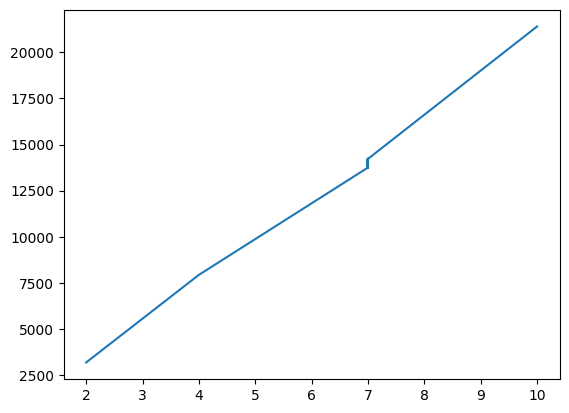

In [173]:
df_sorted = df.sort_values("Length_of_Stay")

plt.plot(
    df_sorted["Length_of_Stay"],
    df_sorted["Total_Hospital_Cost"]
)  #As the number of days a patient stays in the hospital the average hospital cost increases

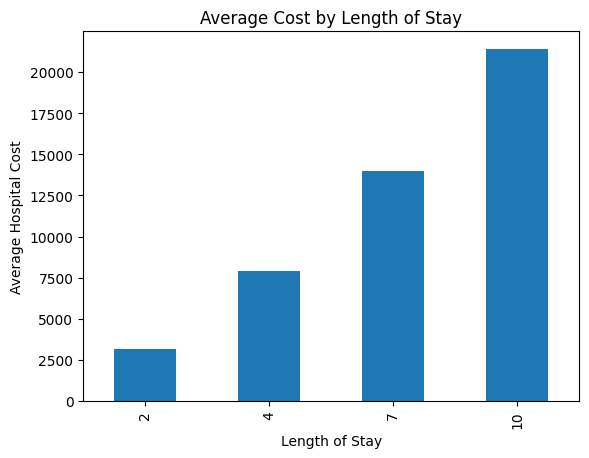

In [172]:
df.groupby("Length_of_Stay")["Total_Hospital_Cost"].mean().plot(kind="bar")

plt.title("Average Cost by Length of Stay")
plt.xlabel("Length of Stay")
plt.ylabel("Average Hospital Cost")

plt.show()

# Key Findings

- Current smokers exhibited higher average cholesterol levels than former and never smokers.
- Patients with diabetes experienced substantially higher rates of 30-day hospital readmissions.
- Hypertension appeared to be associated with increased readmission risk.
- Hospital costs generally increased as length of stay increased.
- Data cleaning was necessary to address missing values, inconsistent categorical labels, formatting issues, and incorrect data types before meaningful analysis could be performed.

# Recommendations

- Develop targeted follow-up programs for patients with chronic conditions such as diabetes and hypertension.
- Encourage smoking cessation initiatives to help reduce cardiovascular risk factors.
- Prioritize discharge planning and post-discharge monitoring for patients identified as high-risk for readmission.
- Continue monitoring factors associated with longer hospital stays, as they contribute significantly to healthcare costs.
- Implement data quality checks to ensure patient information is consistently recorded and maintained.

# Conclusion

This project demonstrated a complete healthcare data analytics workflow using Python, Pandas, Matplotlib, and Jupyter Notebook. The dataset was inspected, cleaned, transformed, and analyzed to identify trends related to patient health outcomes and healthcare utilization. Exploratory data analysis revealed relationships between smoking status and cholesterol levels, chronic conditions and readmissions, and length of stay and hospital costs. The project highlights the importance of data preparation and visualization in supporting healthcare decision-making and identifying areas for further investigation.